# Stage 2 duplex fine-tune -- Colab A100

Runs on `otoSpeech-full-duplex-task-oriented-20h` (gated dataset -- you need an approved HF token).

**Order matters, and two sections below are hard gates, not suggestions:**
- Section 4 (Stage 0 round-trip): per the project spec, do not run training until you've personally listened to the reconstructed audio and confirmed it's intelligible.
- Section 5 (channel roles): `train/stage2_duplex.py` will refuse to start unless you've confirmed which physical audio channel is the user vs. the agent and written that into the config.

Set Runtime -> Change runtime type -> A100 GPU before running anything below.

## 0. Sanity: confirm the A100 is actually attached

In [1]:
!nvidia-smi

Sun Oct  4 17:31:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. Persistent storage (Google Drive)

Colab's local disk is wiped every time the runtime recycles (routinely happens on 12-24h sessions). Processed audio and checkpoints go on Drive so a disconnect doesn't lose hours of preprocessing or training. Only raw intermediate caches should ever live on the ephemeral local disk.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DRIVE_DIR = '/content/drive/MyDrive/S2S-Engine-runs'
os.makedirs(PROJECT_DRIVE_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DRIVE_DIR}/processed', exist_ok=True)
os.makedirs(f'{PROJECT_DRIVE_DIR}/checkpoints', exist_ok=True)
print('Drive mounted. Artifacts will persist under:', PROJECT_DRIVE_DIR)

Mounted at /content/drive
Drive mounted. Artifacts will persist under: /content/drive/MyDrive/S2S-Engine-runs


## 2. Get the code

Clones from GitHub. If you haven't pushed the latest `duplex_speechlm/` changes (dataprep manifest support, Stage 2 training script, duplex fusion, mask-aware variable-length training, channel-role gate, inference script, etc.) to `origin/main` yet, push first -- this clones whatever is on GitHub right now, not your local working copy.

In [3]:
!rm -rf /content/S2S-Engine  # safe to drop a previous failed/partial clone before retrying
!git clone https://github.com/AmulyaJain2004/S2S-Engine.git /content/S2S-Engine
%cd /content/S2S-Engine/duplex_speechlm

Cloning into '/content/S2S-Engine'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 90 (delta 22), reused 78 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 185.16 KiB | 948.00 KiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/S2S-Engine/duplex_speechlm


In [4]:
import os

# HARD CHECK: fail loudly right here if the clone/cd above didn't actually
# land in the repo, instead of a confusing IndexError/FileNotFoundError
# three cells later. If this assert fails: the repo is still private (git
# clone over plain https needs a token unless it's public), or the clone
# cell above errored and you need to scroll up and read that error.
assert os.getcwd() == '/content/S2S-Engine/duplex_speechlm', f'Wrong directory: {os.getcwd()}'
assert os.path.exists('train/stage2_duplex.py'), 'train/stage2_duplex.py missing -- clone did not actually succeed'
print('OK -- repo present at', os.getcwd())

OK -- repo present at /content/S2S-Engine/duplex_speechlm


In [5]:
!pip install -q -r requirements.txt
!pip install -q matplotlib pandas
# Colab preinstalls a torchao version too old for the peft version requirements.txt
# pulls in -- peft probes for torchao whenever it's present and raises instead of
# skipping if the version is incompatible. We don't use torchao anywhere in this
# pipeline, so just remove it rather than pin a version to chase compatibility.
!pip uninstall -y -q torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 83.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 3. Hugging Face auth

Needs a token with approved access to `otoearth/otoSpeech-full-duplex-task-oriented-20h`. This will prompt for the token interactively -- paste it, don't hardcode it in a cell.

In [6]:
from huggingface_hub import login
login()

## 4. STAGE 0 GATE -- preprocess one session, then listen

Pulls exactly one real session (so this is fast) and runs the WavLM -> Vocos round trip on a 5s slice of it. **Listen to both audio players that appear below.** If the reconstruction is noise, garbled, or clearly degraded, STOP -- something in the Vocos mel config is off, and training on top of it is wasted GPU time. Go back to `vocoder/mel_utils.py` / re-verify against the installed `vocos` package before proceeding.

In [7]:
!python dataprep/preprocess_otospeech.py --output_dir /content/one_session_check --max_sessions 1

session session_ff1f3456bb828a9d: 1494.3s, events 95/95/35 (total/usable/interaction-primary), redacted spans muted: 0

=== FULL PREPROCESSING REPORT ===
sessions newly processed: 1
sessions skipped (already done): 0
sessions failed:          0
total sessions in manifest: 1
total audio in manifest:    0.42h
manifest written to:        /content/one_session_check/manifest.json


In [8]:
import glob, soundfile as sf

session_dir = glob.glob('/content/one_session_check/session_*')[0]
wav_path = f'{session_dir}/speaker_0.wav'
data, sr = sf.read(wav_path)

# Start partway into the session, not at sample 0 -- real conversational
# recordings routinely have a few seconds of dead air / line noise / room
# tone before anyone speaks, and grabbing that as the P0 "original" clip
# looks exactly like a broken pipeline even when nothing is wrong. 60s in
# (or 30% of the session if it's shorter than ~200s) is far more likely to
# land on actual speech.
duration_s = len(data) / sr
offset_s = min(60.0, duration_s * 0.3)
start = int(offset_s * sr)
clip = data[start : start + int(5 * sr)]

clip_path = '/content/p0_input_clip.wav'
sf.write(clip_path, clip, sr)
print(f'Using clip: {clip_path} (from {offset_s:.1f}s into a {duration_s:.1f}s session)')

Using clip: /content/p0_input_clip.wav (from 60.0s into a 1494.3s session)


In [9]:
!python scripts/p0_roundtrip.py --wav /content/p0_input_clip.wav

Loading input audio...
Loading WavLM (frozen)...
preprocessor_config.json: 100% 215/215 [00:00<00:00, 740kB/s]
config.json: 100% 2.23k/2.23k [00:00<00:00, 3.14MB/s]

pytorch_model.bin: downloading bytes:  32% 122M/378M [00:01<00:02, 118MB/s, 6.59MB/s  ]  
pytorch_model.bin: downloading bytes:  51% 192M/378M [00:01<00:01, 177MB/s, 15.0MB/s  ]
pytorch_model.bin: reconstructing file:  36% 134M/378M [00:01<00:02, 85.2MB/s, 6.42MB/s  ]
pytorch_model.bin: downloading bytes: 100% 254M/254M [00:02<00:00, 118MB/s, 23.6MB/s  ]
pytorch_model.bin: reconstructing file: 100% 378M/378M [00:02<00:00, 175MB/s, 35.4MB/s  ]
Loading weights: 100% 248/248 [00:00<00:00, 19053.49it/s]

model.safetensors: downloading bytes:   0% 0.00/378M [00:00<?, ?B/s]/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Loading Vocos (frozen)...
model.safeten

In [10]:
from IPython.display import Audio, display
print('ORIGINAL:')
display(Audio('outputs/p0_original.wav'))
print('RECONSTRUCTED (WavLM features are not involved in this reconstruction -- this is Vocos alone -- '
      'but a bad result here still means the mel config is wrong, which the acoustic head trains against):')
display(Audio('outputs/p0_reconstructed.wav'))

ORIGINAL:


RECONSTRUCTED (WavLM features are not involved in this reconstruction -- this is Vocos alone -- but a bad result here still means the mel config is wrong, which the acoustic head trains against):


### STOP HERE until you've listened.

Only run the cells below once the reconstruction above sounds like intelligible speech (it will not be identical to the original -- Vocos is lossy -- but it must not be noise).

## 5. GATE -- confirm speaker-channel roles

`dataprep/print_channel_roles.py` prints the real `speakers_by_channel` metadata from this session (plus `task_info` and a labelled best-effort guess) so you can read it yourself.

**Heads up:** otoSpeech-task-oriented-20h may turn out to be peer-to-peer conversation data (both speakers generically labeled `"task_role_name": "speaker"`, no inherent "agent" vs "user" role) rather than a customer/agent transcript -- the script will print an explicit note if that's the case. If so, `user_channel`/`agent_channel` isn't "which one is really the user" (there may be no such thing); it's just a fixed, consistent choice of which channel the model learns to produce vs. treats as incoming audio. Any consistent choice is valid for Stage 2's actual goal (duplex turn-taking/backchannel timing) -- it just has to be the SAME channel index for every session, which the script's consistency check verifies. `train/stage2_duplex.py` still hard-refuses to start training until `audio.channel_roles_verified: true` is set in the config written in Section 7 -- this is not optional to skip, even when the choice is arbitrary, because it forces you to make the choice deliberately rather than by accident.

In [11]:
!python dataprep/print_channel_roles.py --manifest /content/one_session_check/manifest.json --n_sessions 1

Inspecting 1 of 1 sessions in /content/one_session_check/manifest.json

--- session session_ff1f3456bb828a9d ---
{
  "0": {
    "accent": "United States",
    "accent_group": "American",
    "age": 0,
    "birth_country": "United States",
    "channel": 0,
    "dialect": "",
    "education_level": "",
    "first_language": "English",
    "gender": "male",
    "job": "",
    "mbti": "",
    "name": "",
    "nationality": "United States",
    "residence_country": "United States",
    "second_language": "",
    "speaker_id": "speaker_68c966ba7e9e9bd0",
    "task_role": 0,
    "task_role_name": "speaker"
  },
  "1": {
    "accent": "American",
    "accent_group": "American",
    "age": 0,
    "birth_country": "United States",
    "channel": 1,
    "dialect": "",
    "education_level": "High school",
    "first_language": "English",
    "gender": "female",
    "job": "Work from home",
    "mbti": "",
    "name": "",
    "nationality": "United States",
    "residence_country": "United States

Read the printed JSON above yourself (the 'guess' is only a heuristic). Set the two variables below to match what you actually confirmed, then move on to Section 6 -- Section 7 uses these variables when it writes the training config and will NOT silently default to an unverified guess.

In [16]:
# EDIT THESE after reading Section 5's output -- there is no safe default.
CONFIRMED_USER_CHANNEL = 0   # the channel you confirmed is the user/customer side
CONFIRMED_AGENT_CHANNEL = 1  # the channel you confirmed is the agent side
I_HAVE_VERIFIED_CHANNEL_ROLES = True  # set True only after you've actually read Section 5's output

## 6. Preprocess the full (or a capped subset of the) dataset onto Drive

This streams every session and writes `processed/session_*/` + `processed/manifest.json`. It's resumable: re-running with the same `--output_dir` skips sessions already in the manifest, so a Colab disconnect mid-preprocessing doesn't force a restart from zero.

Start with `--max_sessions 20` or so to get a first Stage 2 run going quickly; drop the flag (or raise it) later to use more of the 20h.

If your dataset has many sessions and/or speaker roles might not be assigned to the same channel every session, also widen the `--n_sessions` check in Section 5 against this full manifest once it exists (re-run that cell pointed at `$PROCESSED_DIR/manifest.json`) -- `print_channel_roles.py` will warn you explicitly if the channel-to-role mapping is inconsistent across sessions, in which case a single global `user_channel`/`agent_channel` is the wrong model and this needs revisiting before training.

In [17]:
PROCESSED_DIR = f'{PROJECT_DRIVE_DIR}/processed'
!python dataprep/preprocess_otospeech.py --output_dir "$PROCESSED_DIR" --max_sessions 20

Muted 1 redacted segment(s) in both channels.
session session_e30f5efd60408da7: 955.7s, events 85/85/12 (total/usable/interaction-primary), redacted spans muted: 1
session session_e8338960305c2950: 914.7s, events 119/119/36 (total/usable/interaction-primary), redacted spans muted: 0
session session_23a7c3fca463922d: 1493.4s, events 280/280/96 (total/usable/interaction-primary), redacted spans muted: 0
session session_97782d2cdc3b323e: 1494.5s, events 277/277/98 (total/usable/interaction-primary), redacted spans muted: 0
session session_bfe290078723cbd9: 1494.8s, events 421/421/163 (total/usable/interaction-primary), redacted spans muted: 0
session session_a4cdb13c0a908a5c: 1493.6s, events 269/269/96 (total/usable/interaction-primary), redacted spans muted: 0
Muted 1 redacted segment(s) in both channels.
session session_e98f86ffac6cc553: 1313.3s, events 121/121/18 (total/usable/interaction-primary), redacted spans muted: 1
session session_e7ec7258cdf5f436: 1494.5s, events 341/341/307 (t

Re-run the cell above (bump `--max_sessions`, or drop it entirely) whenever you want more data processed -- it only does new sessions.

## 7. Write a Colab-specific config pointing at Drive paths

In [18]:
import yaml

assert I_HAVE_VERIFIED_CHANNEL_ROLES, (
    'Section 5 was not confirmed -- read its output and flip I_HAVE_VERIFIED_CHANNEL_ROLES to True '
    'before writing a config. train/stage2_duplex.py will refuse to train otherwise anyway.'
)

with open('configs/stage2.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['paths']['manifest_path'] = f'{PROCESSED_DIR}/manifest.json'
cfg['paths']['checkpoint_dir'] = f'{PROJECT_DRIVE_DIR}/checkpoints/stage2'
cfg['audio']['user_channel'] = CONFIRMED_USER_CHANNEL
cfg['audio']['agent_channel'] = CONFIRMED_AGENT_CHANNEL
cfg['audio']['channel_roles_verified'] = True
# cfg['train']['batch_size'] = 4     # raise if nvidia-smi shows headroom

with open('configs/stage2_colab.yaml', 'w') as f:
    yaml.safe_dump(cfg, f)

print(yaml.safe_dump(cfg))

audio:
  agent_channel: 1
  channel_roles_verified: true
  chunk_duration_s: 8.0
  min_chunk_s: 1.0
  n_mels: 100
  user_channel: 0
lora:
  alpha: 32
  dropout: 0.05
  r: 16
models:
  qwen_name: Qwen/Qwen2.5-1.5B-Instruct
  vocos_repo: charactr/vocos-mel-24khz
  wavlm_name: microsoft/wavlm-base-plus
paths:
  checkpoint_dir: /content/drive/MyDrive/S2S-Engine-runs/checkpoints/stage2
  manifest_path: /content/drive/MyDrive/S2S-Engine-runs/processed/manifest.json
runtime:
  device: cuda
  dtype: bf16
train:
  batch_size: 4
  log_every: 10
  lr: 0.0002
  max_steps: 20000
  num_workers: 4
  save_every: 500



## 8. Train

Checkpoints + `train_log.csv` write to Drive every `save_every` steps, so if Colab disconnects, just re-run this cell -- it resumes from the last saved checkpoint automatically (see `try_resume` in `train/stage2_duplex.py`). Training chunks have variable length (each session's trailing remainder is kept, not dropped) and are mask-aware end to end, so this uses real data more completely than a naive fixed-length-only chunker would.

Tip: for a quick pipeline sanity check before committing to a long run, temporarily lower `max_steps` in `configs/stage2.yaml` (e.g. to 200) before writing Section 7's config, then run Section 10 below against that tiny checkpoint just to confirm generation runs end to end -- it won't sound good yet, but it proves nothing is structurally broken before you spend hours training for real.

In [19]:
!python train/stage2_duplex.py --config configs/stage2_colab.yaml

Device: cuda, dtype: torch.bfloat16
Loading weights: 100% 248/248 [00:00<00:00, 18534.40it/s]
config.json: 100% 660/660 [00:00<00:00, 2.88MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 13.3MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 15.1MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 11.8MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 10.7MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!

model.safetensors: downloading bytes:   0% 0.00/3.09G [00:00<?, ?B/s]
model.safetensors: downloading bytes:   4% 131M/3.09G [00:02<00:16, 184MB/s, 9.03MB/s  ] 
model.safetensors: downloading bytes:   5% 166M/3.09G [00:02<00:13, 223MB/s, 12.1MB/s  ]
model.safetensors: downloading bytes:   6% 197M/3.09G [00:02<00:11, 243MB/s, 15.3MB/s  ]
model.safetensors: downloading bytes:  17% 536M/3.09G [00:03<00:05, 433MB/s, 41.4MB/s  ]
model.safetensors: downloading bytes:  22% 681M/3.09G [00:03<00:05, 470MB/s, 53.1MB/s  ]
model.safetensors: downloading bytes:  27% 825M

## 9. Plot training loss (run anytime, even while training is still going in another cell)

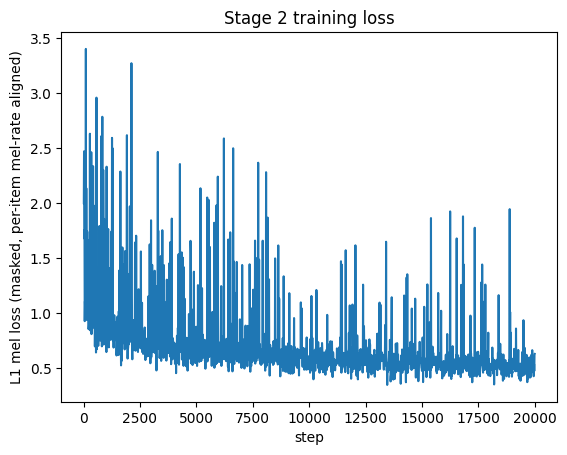

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv(f'{PROJECT_DRIVE_DIR}/checkpoints/stage2/train_log.csv')
plt.plot(log['step'], log['loss'])
plt.xlabel('step'); plt.ylabel('L1 mel loss (masked, per-item mel-rate aligned)'); plt.title('Stage 2 training loss')
plt.show()

## 10. Generate and listen (the real test)

A falling loss curve does not by itself mean the output is intelligible or well-timed -- this is the only way to actually check. `eval/generate_stage2.py` loads the trained checkpoint and runs genuine autoregressive duplex generation: the model's own synthesized audio from each ~0.4s window feeds back into the NEXT window's duplex fusion (unlike training, which teacher-forces that feedback with ground-truth audio -- see the exposure-bias note at the top of that script). Feeds in a real user-channel clip it was never trained on (a different session than the Stage 0 check) and listens to what comes out.

In [24]:
!python dataprep/preprocess_otospeech.py --output_dir /content/holdout_check --max_sessions 1

session session_70fc7eacedfc353a: 978.4s, events 67/67/10 (total/usable/interaction-primary), redacted spans muted: 0

=== FULL PREPROCESSING REPORT ===
sessions newly processed: 1
sessions skipped (already done): 1
sessions failed:          0
total sessions in manifest: 2
total audio in manifest:    0.69h
manifest written to:        /content/holdout_check/manifest.json


The cell above streams the NEXT unseen session (it skips any session already in `/content/one_session_check` or your processed manifest by id, since `preprocess_all_sessions` keys on session_id across the whole stream -- if it happens to land on a session already used for training, just point `--user_wav` below at a different `processed/session_*/speaker_<CONFIRMED_USER_CHANNEL>.wav` from your full manifest instead).

In [27]:
from IPython.display import Audio, display

print('INPUT (what the model heard):')
display(Audio('/content/generation_check/input_user.wav'))
print('GENERATED (self-feedback autoregressive, NOT teacher-forced -- the honest result):')
display(Audio('/content/generation_check/generated_agent.wav'))

INPUT (what the model heard):


GENERATED (self-feedback autoregressive, NOT teacher-forced -- the honest result):


In [26]:
import glob

holdout_dir = glob.glob('/content/holdout_check/session_*')[0]
holdout_user_wav = f'{holdout_dir}/speaker_{CONFIRMED_USER_CHANNEL}.wav'
print('Using held-out user clip:', holdout_user_wav)

!python eval/generate_stage2.py \
    --config configs/stage2_colab.yaml \
    --user_wav "$holdout_user_wav" \
    --window_s 0.4 \
    --max_duration_s 30 \
    --out_dir /content/generation_check

Using held-out user clip: /content/holdout_check/session_session_70fc7eacedfc353a/speaker_0.wav
Loading weights: 100% 248/248 [00:00<00:00, 19083.21it/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:00<00:00, 5330.49it/s]
/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:331: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Loaded checkpoint from step 20000 at /content/drive/MyDrive/S2S-Engine-runs/checkpoints/stage2
Generating 75 window(s) of 0.4s each from checkpoint step 20000 (self-feedback, KV-cached Qwen)...
/usr/local/lib/python3.13/dist-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
  window 10/75 done
  window 20/75 done
  window 30/75 do